# HW5 – Histograma rápido en CUDA
Introduction to Parallel Programming (Udacity CS344).

**Antes de empezar:** Entorno de ejecución → Cambiar tipo de entorno → **GPU (T4)**. Luego ejecuta las celdas en orden.

In [ ]:
!nvidia-smi

## 1. Clonar el repositorio
HW5 no usa OpenCV, así que se compila directo con `nvcc` (sin CMake).

In [1]:
%cd /content
!rm -rf udacity-cs344-colab
!git clone https://github.com/depctg/udacity-cs344-colab.git
!ls /content/udacity-cs344-colab/src/HW5

/content
Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 21.32 MiB/s, done.
Resolving deltas: 100% (43/43), done.
CMakeLists.txt	Makefile	    reference_calc.h  timer.h
main.cu		reference_calc.cpp  student.cu	      utils.h


## 2. Código del estudiante
Histograma privado por bloque en memoria compartida + combinación con `atomicAdd` en memoria global.

In [2]:
%%writefile /content/udacity-cs344-colab/src/HW5/student.cu
/*
 * HW5 - Histograma rápido en CUDA
 * Curso: Introduction to Parallel Programming (Udacity CS344)
 *
 * Idea de la paralelización:
 *  - Cada hilo recorre el arreglo de entrada con un "grid-stride loop",
 *    así pocos bloques cubren los ~10 millones de elementos.
 *  - Versión ingenua (histoGlobal): cada hilo hace atomicAdd directo sobre el
 *    histograma en memoria global. Muchos hilos chocan en los mismos bins
 *    (la distribución es normal, así que los bins centrales se saturan).
 *  - Versión optimizada (yourHisto): cada bloque construye un histograma
 *    PRIVADO en memoria compartida (mucho más rápida y con menos contención),
 *    y al final suma su histograma parcial al global con un atomicAdd por bin.
 *
 * Variables de entorno opcionales (no cambian el resultado):
 *   HISTO_MODO=global   -> usa la versión ingenua, para comparar tiempos
 *   GUARDAR_HISTO=1     -> guarda el histograma en histograma.txt para graficarlo
 */

#include "utils.h"
#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <vector>

// ---------------------------------------------------------------------------
// Versión 1 (ingenua): atomicAdd directo en memoria global
// ---------------------------------------------------------------------------
__global__
void histoGlobal(const unsigned int* const vals,
                 unsigned int* const histo,
                 int numVals)
{
  int idx    = blockIdx.x * blockDim.x + threadIdx.x;
  int stride = blockDim.x * gridDim.x;
  for (int i = idx; i < numVals; i += stride)
    atomicAdd(&histo[vals[i]], 1u);
}

// ---------------------------------------------------------------------------
// Versión 2 (optimizada): histograma privado por bloque en memoria compartida
// ---------------------------------------------------------------------------
__global__
void yourHisto(const unsigned int* const vals, //INPUT
               unsigned int* const histo,      //OUTPUT
               int numVals,
               int numBins)
{
  extern __shared__ unsigned int s_histo[];

  // 1) Inicializar el histograma local del bloque
  for (int b = threadIdx.x; b < numBins; b += blockDim.x)
    s_histo[b] = 0;
  __syncthreads();

  // 2) Cada hilo procesa varios elementos (grid-stride loop)
  int idx    = blockIdx.x * blockDim.x + threadIdx.x;
  int stride = blockDim.x * gridDim.x;
  for (int i = idx; i < numVals; i += stride)
    atomicAdd(&s_histo[vals[i]], 1u);
  __syncthreads();

  // 3) Combinar el histograma local con el global (un atómico por bin)
  for (int b = threadIdx.x; b < numBins; b += blockDim.x) {
    unsigned int c = s_histo[b];
    if (c) atomicAdd(&histo[b], c);
  }
}

void computeHistogram(const unsigned int* const d_vals, //INPUT
                      unsigned int* const d_histo,      //OUTPUT
                      const unsigned int numBins,
                      const unsigned int numElems)
{
  // El histograma de salida debe empezar en cero
  checkCudaErrors(cudaMemset(d_histo, 0, sizeof(unsigned int) * numBins));

  // Configuración de lanzamiento: unos pocos bloques por multiprocesador
  int device, numSMs;
  checkCudaErrors(cudaGetDevice(&device));
  checkCudaErrors(cudaDeviceGetAttribute(&numSMs, cudaDevAttrMultiProcessorCount, device));
  const int threads = 256;
  const int blocks  = numSMs * 8;
  const size_t shmem = numBins * sizeof(unsigned int);

  const char* modo = getenv("HISTO_MODO");
  bool usarGlobal = (modo && strcmp(modo, "global") == 0) || shmem > 48 * 1024;

  if (usarGlobal)
    histoGlobal<<<blocks, threads>>>(d_vals, d_histo, numElems);
  else
    yourHisto<<<blocks, threads, shmem>>>(d_vals, d_histo, numElems, numBins);

  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());

  // Opcional: guardar el histograma para graficarlo en Colab
  if (getenv("GUARDAR_HISTO")) {
    std::vector<unsigned int> h(numBins);
    checkCudaErrors(cudaMemcpy(h.data(), d_histo, shmem, cudaMemcpyDeviceToHost));
    FILE* f = fopen("histograma.txt", "w");
    if (f) {
      for (unsigned int b = 0; b < numBins; ++b) fprintf(f, "%u\n", h[b]);
      fclose(f);
    }
  }
}


Overwriting /content/udacity-cs344-colab/src/HW5/student.cu


## 3. Compilar

In [3]:
%cd /content/udacity-cs344-colab/src/HW5
!nvcc -O3 -arch=native -o /content/hw5 main.cu student.cu reference_calc.cpp || nvcc -O3 -arch=sm_75 -o /content/hw5 main.cu student.cu reference_calc.cpp
exe = ['/content/hw5']
!ls -la /content/hw5

/content/udacity-cs344-colab/src/HW5
-rwxr-xr-x 1 root root 1021736 Sep 29 16:33 /content/hw5


## 4. Ejecutar la versión optimizada (memoria compartida)

In [4]:
%cd /content
!{exe[0]}

/content
463
Your code ran in: 0.344416 msecs.


## 5. Comparar con la versión ingenua (atómicos en memoria global)

In [5]:
!HISTO_MODO=global {exe[0]}

480
Your code ran in: 4.763040 msecs.


## 6. Visualizar el histograma calculado en la GPU

478
Your code ran in: 0.683456 msecs.


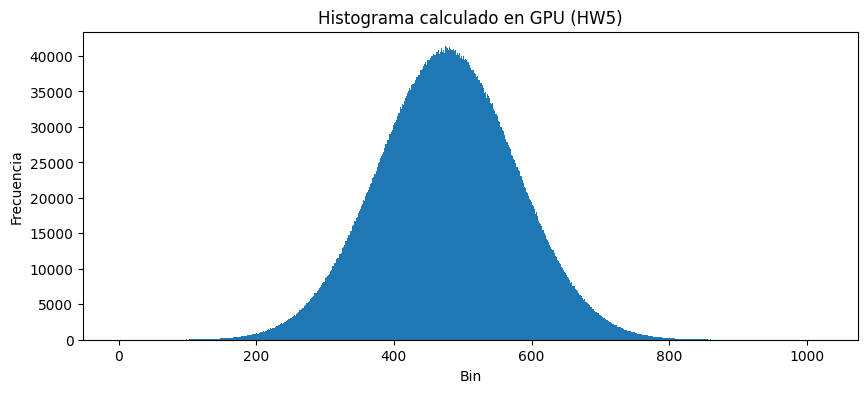

Total de elementos contados: 10240000


In [6]:
!GUARDAR_HISTO=1 {exe[0]}

import numpy as np, matplotlib.pyplot as plt
h = np.loadtxt('/content/histograma.txt')
plt.figure(figsize=(10,4))
plt.bar(np.arange(len(h)), h, width=1.0)
plt.title('Histograma calculado en GPU (HW5)')
plt.xlabel('Bin'); plt.ylabel('Frecuencia')
plt.show()
print('Total de elementos contados:', int(h.sum()))